In [3]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr, pearsonr

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(HERE, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
NOTEBOOKS_DIR = os.path.join(PROJECT_ROOT, "notebooks")
if NOTEBOOKS_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOKS_DIR)

from cls.utils.GridUtils import VectorHash, smooth_gbook, smooth_g
from cls.envs.environments import GridWMEnv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda


# Vector Hash Playground

## 1. Setup: Scaffold (Grid + Place Cells Only)

In [21]:
# # --- With Sensory Maps ---
lambdas = [3, 4, 5]
Ng = int(np.sum(np.square(lambdas)))
Npos = int(np.prod(lambdas))
size = 12
n_envs = 1
Np = 400
thresh = 0.5
c = 0.5
observation_size = 3600
fwhm_ratio = 0.25

# --- Build scaffold + environments ---
envs = [GridWMEnv(size=size, speed=1, observation_size=observation_size) for _ in range(n_envs)]

vh = VectorHash(
    Np=Np,
    lambdas=lambdas,
    size=size,
    Npos=Npos,
    thresh=thresh,
    c=c,
)
vh.initiate_vectorhash(envs)

print(f"Scaffold ready: pbook {vh.pbook.shape}, gbook {vh.gbook.shape}")
print(f"Sensory maps: Wps {vh.Wps.shape}, Wsp {vh.Wsp.shape}")
print(f"Env locations: {vh.env_locations}")

   setup scaffold
      gen_gbook_2d
gbook shape: (50, 60, 60)
Wpg shape: (400, 50)
      pbook
pbook shape: (400, 60, 60)
      train_gcpc
Wgp shape: (50, 400)
   setup envs
   initialize envs vh
   testing vectorhash recall on 144 samples...
   shapes: path_sbook=(3600, 144), path_pbook=(400, 144), path_gbook=(50, 144)
   Wps=(400, 3600), Wgp=(50, 400), thresh=0.5
   unique s: 144/144, unique p: 144/144
   sample 0: p_raw max=3.614 min=-0.000 argmax=9 | p_true argmax=9 nnz=122
   sample 1: p_raw max=4.325 min=-0.000 argmax=41 | p_true argmax=41 nnz=127
   sample 2: p_raw max=3.852 min=-0.000 argmax=214 | p_true argmax=214 nnz=147
   s→p exact: 0/144 (0.0%)
   s→p argmax: 144/144 (100.0%)
   s→p→g→p roundtrip: 144/144 (100.0%)
   grid recovery: 144/144 (100.0%)
   p→g direct: 144/144 correct (100.0%)
   g→p direct: 144/144 correct (100.0%)
Scaffold ready: pbook (400, 60, 60), gbook (50, 60, 60)
Sensory maps: Wps (400, 3600), Wsp (3600, 400)
Env locations: [(22, 17)]


In [31]:
# --- Parameters ---
lambdas = [5,7,11,12,13,17]
Ng = int(np.sum(np.square(lambdas)))
Npos = int(np.prod(lambdas))
Np = 1000
thresh = 2.5
fwhm_ratio = 0.5  # smooth grid codes before hpc projection. 0 = one-hot (no smoothing).
c = 0.5

# --- Build scaffold only (no sensory/env needed) ---
vh = VectorHash(
    Np=Np,
    lambdas=lambdas,
    size=1,  # unused, just needed for constructor
    Npos=Npos,
    thresh=thresh,
    c=c,
)
pbook, pbook_flat, gbook, gbook_flat, Wpg, Wgp, module_sizes, module_gbooks = vh.setup_scaffold(Np, lambdas, thresh)

# Optionally smooth grid codes and recompute place codes
if fwhm_ratio > 0:
    from cls.vectorhash.assoc_utils_np import train_pbook, nonlin
    gbook_smooth = smooth_gbook(gbook, lambdas, fwhm_ratio)
    pbook = nonlin(train_pbook(Wpg, gbook_smooth), thresh=thresh)
    gbook = gbook_smooth
    print(f"Smoothed grid codes with fwhm_ratio={fwhm_ratio}, recomputed pbook")

# Store on vh for convenience in later cells
vh.pbook = pbook
vh.gbook = gbook
vh.Wpg = Wpg
vh.Wgp = Wgp

print(f"Scaffold ready: pbook {pbook.shape}, gbook {gbook.shape}")
print(f"Wpg {Wpg.shape}, Wgp {Wgp.shape}")

      gen_gbook_2d


MemoryError: Unable to allocate 5.90 PiB for an array with shape (797, 1021020, 1021020) and data type float64

## 2. Place Field Visualizations

Classic place cell tuning curves: for selected place cells, plot their activity across all positions in the scaffold.

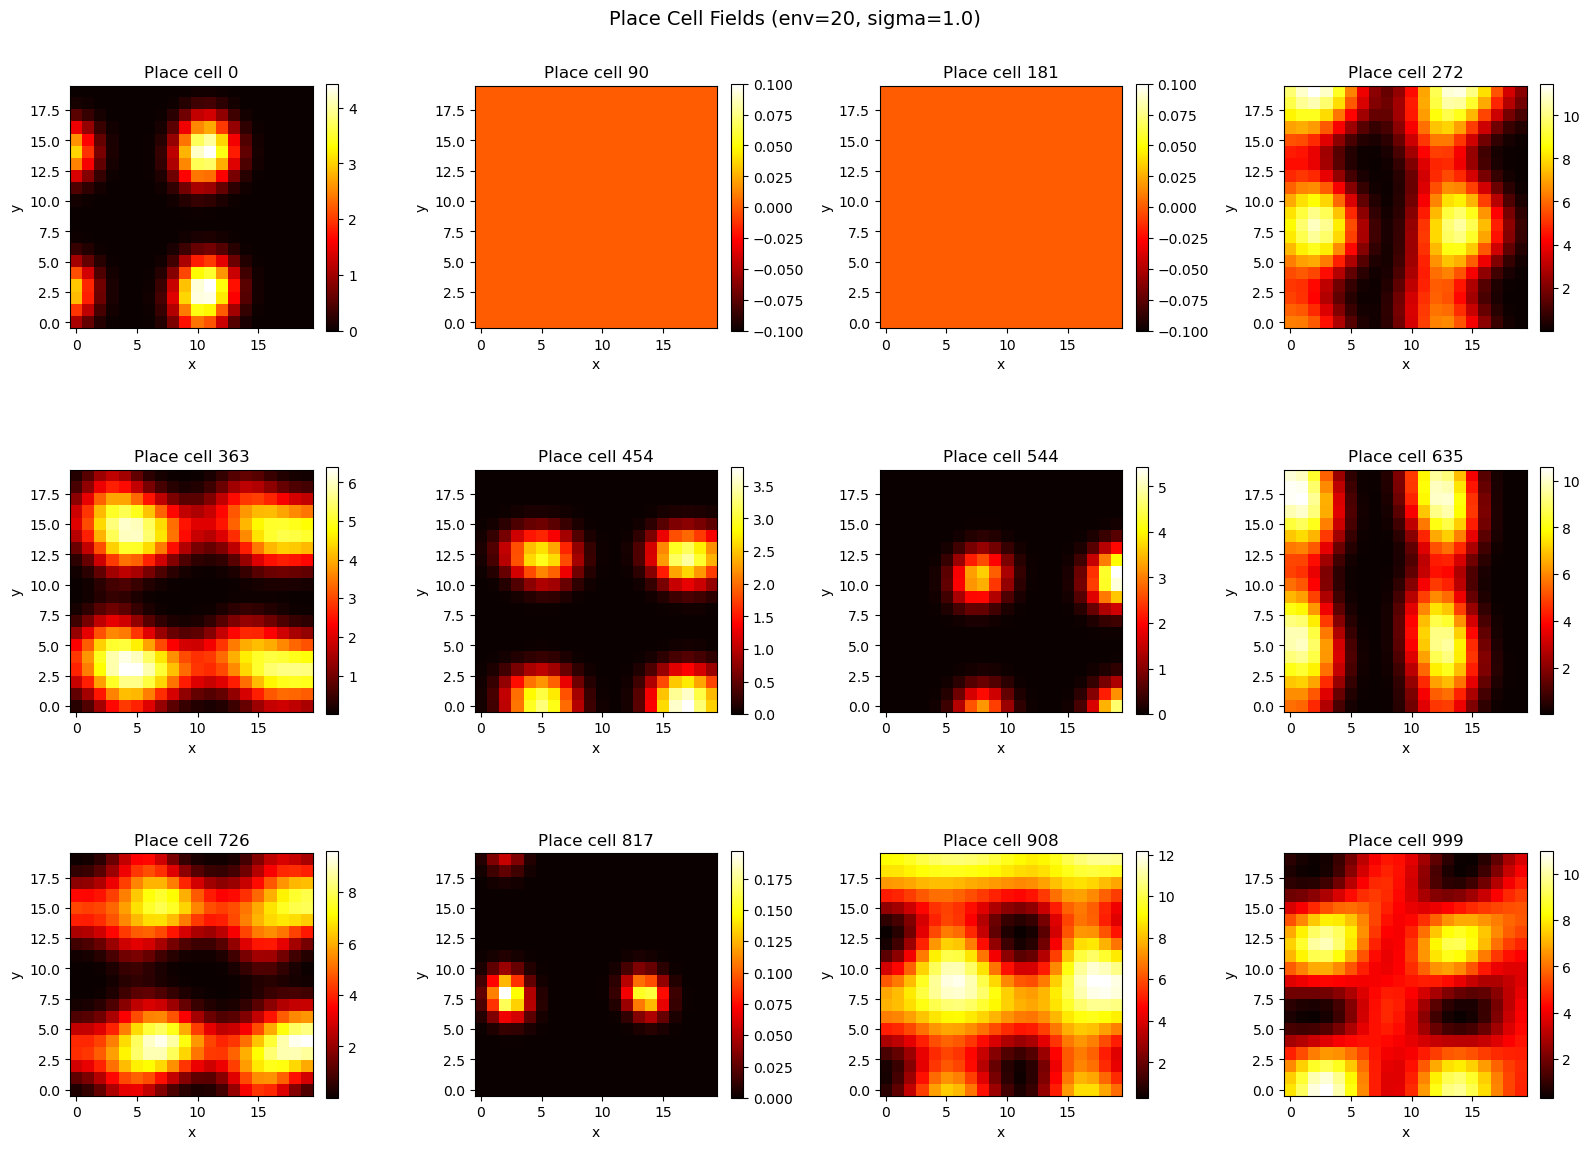

In [28]:
# --- Place fields from pbook ---
from scipy.ndimage import gaussian_filter

sigma_smooth_viz = 1.0  # Gaussian smoothing for visualization. 0 = raw.
env_size_viz = 20  # crop to this square from center. None = full scaffold.

n_show = 12
cell_indices = np.linspace(0, Np - 1, n_show, dtype=int)

# Crop region
if env_size_viz is not None:
    cx, cy = Npos // 2, Npos // 2
    sl = (slice(cx - env_size_viz // 2, cx + env_size_viz // 2),
          slice(cy - env_size_viz // 2, cy + env_size_viz // 2))
else:
    sl = (slice(None), slice(None))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, ci in zip(axes.flat, cell_indices):
    field = vh.pbook[ci][sl[0], sl[1]]
    if sigma_smooth_viz > 0:
        field = gaussian_filter(field, sigma=sigma_smooth_viz)
    im = ax.imshow(field, origin="lower", cmap="hot", interpolation="nearest")
    ax.set_title(f"Place cell {ci}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Place Cell Fields (env={env_size_viz}, sigma={sigma_smooth_viz})", fontsize=14)
plt.tight_layout()
plt.show()

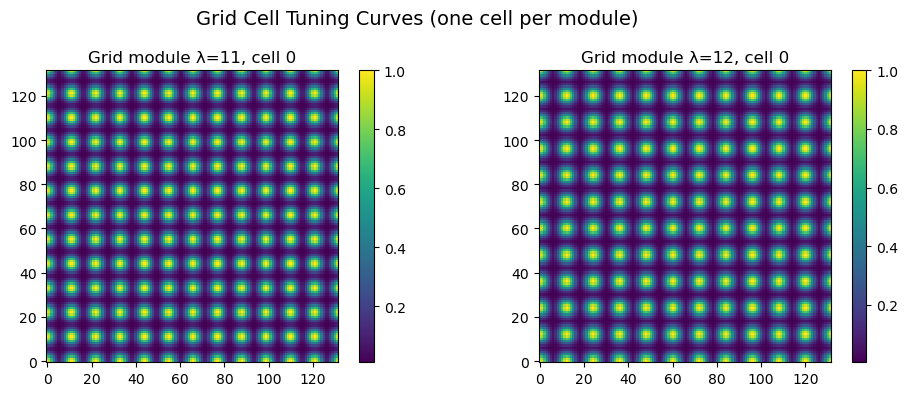

In [23]:
# --- Grid cell tuning curves (individual modules) ---
# gbook shape: (Ng, Npos, Npos)
# Show one grid cell per module

fig, axes = plt.subplots(1, len(lambdas), figsize=(5 * len(lambdas), 4))
offset = 0
for ax, lam in zip(axes, lambdas):
    # Pick the first grid cell in this module (the one active at position (0,0))
    field = vh.gbook[offset]  # (Npos, Npos) — periodic tiling
    im = ax.imshow(field, origin="lower", cmap="viridis", interpolation="nearest")
    ax.set_title(f"Grid module λ={lam}, cell 0")
    plt.colorbar(im, ax=ax, fraction=0.046)
    offset += lam ** 2
fig.suptitle("Grid Cell Tuning Curves (one cell per module)", fontsize=14)
plt.tight_layout()
plt.show()

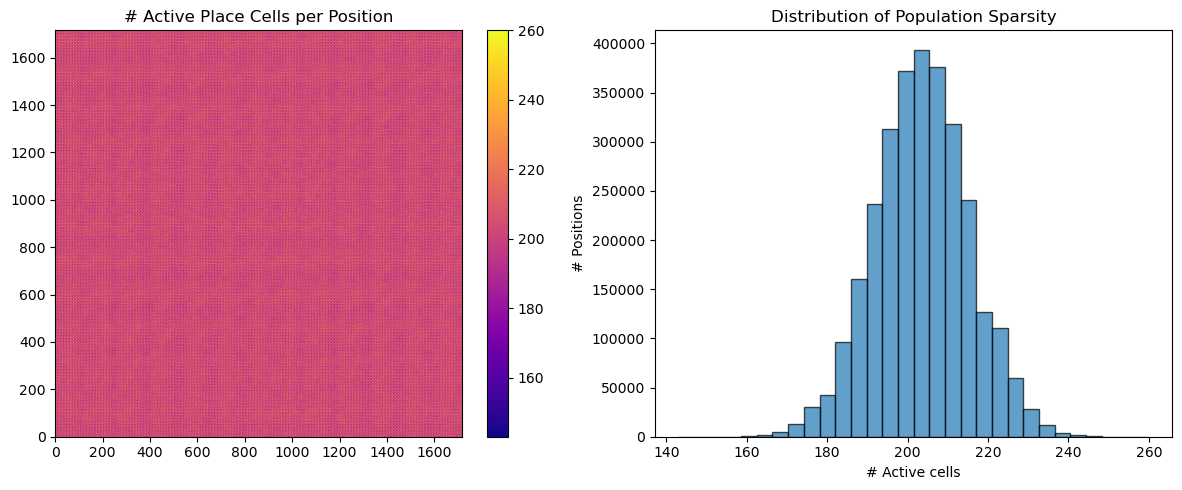

Mean active cells per position: 203.5 / 1000
Sparsity: 0.797


In [9]:
# --- Population sparsity: fraction of active place cells per position ---
active_counts = (vh.pbook > 0).sum(axis=0)  # (Npos, Npos)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(active_counts, origin="lower", cmap="plasma")
axes[0].set_title("# Active Place Cells per Position")
plt.colorbar(im0, ax=axes[0])

axes[1].hist(active_counts.flatten(), bins=30, edgecolor="k", alpha=0.7)
axes[1].set_xlabel("# Active cells")
axes[1].set_ylabel("# Positions")
axes[1].set_title("Distribution of Population Sparsity")

plt.tight_layout()
plt.show()

print(f"Mean active cells per position: {active_counts.mean():.1f} / {Np}")
print(f"Sparsity: {1 - active_counts.mean() / Np:.3f}")

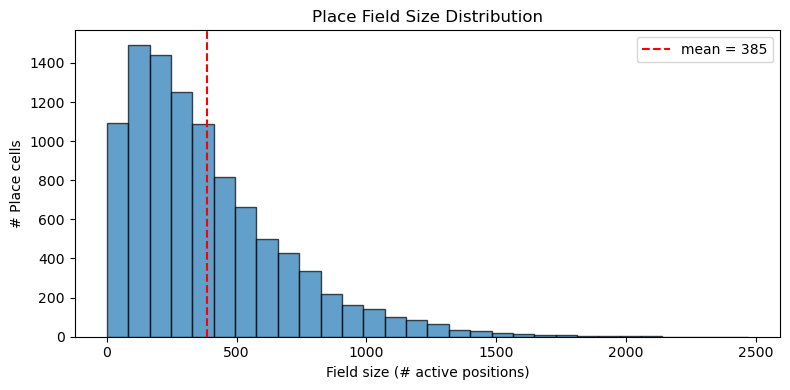

In [12]:
# --- Place field sizes: number of positions where each cell is active ---
field_sizes = (vh.pbook > 0).reshape(Np, -1).sum(axis=1)  # (Np,)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(field_sizes, bins=30, edgecolor="k", alpha=0.7)
ax.set_xlabel("Field size (# active positions)")
ax.set_ylabel("# Place cells")
ax.set_title("Place Field Size Distribution")
ax.axvline(field_sizes.mean(), color="red", ls="--", label=f"mean = {field_sizes.mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Hippocampal Representation: Similarity x Distance Analysis

Compute cosine similarity between place-cell population vectors as a function of spatial distance, analogous to the encoder-level analysis in `similarity_testing`.

In [29]:
# --- Extract env-sized square from center of scaffold ---
from scipy.ndimage import gaussian_filter

env_size = None  # same as the environment grid size

if env_size is None: env_size = Npos
cx, cy = Npos // 2, Npos // 2
x0, x1 = cx - env_size // 2, cx + env_size // 2
y0, y1 = cy - env_size // 2, cy + env_size // 2

# Crop pbook to the env square: (Np, env_size, env_size)
pbook_env = vh.pbook[:, x0:x1, y0:y1].copy()

# Population vectors: (env_size*env_size, Np)
pop_vectors = pbook_env.reshape(Np, env_size * env_size).T

# Local coordinates within the square
ys, xs = np.mgrid[0:env_size, 0:env_size]
coords = np.stack([xs.ravel(), ys.ravel()], axis=1).astype(np.float32)

# Normalized version for cosine similarity
norms = np.linalg.norm(pop_vectors, axis=1, keepdims=True)
norms = np.maximum(norms, 1e-12)
pop_normed = pop_vectors / norms

print(f"Env square: [{x0}:{x1}, {y0}:{y1}] in scaffold ({Npos}x{Npos})")
print(f"Population vectors: {pop_vectors.shape}")
print(f"Coordinates: {coords.shape}")

Env square: [0:132, 0:132] in scaffold (132x132)
Population vectors: (17424, 1000)
Coordinates: (17424, 2)


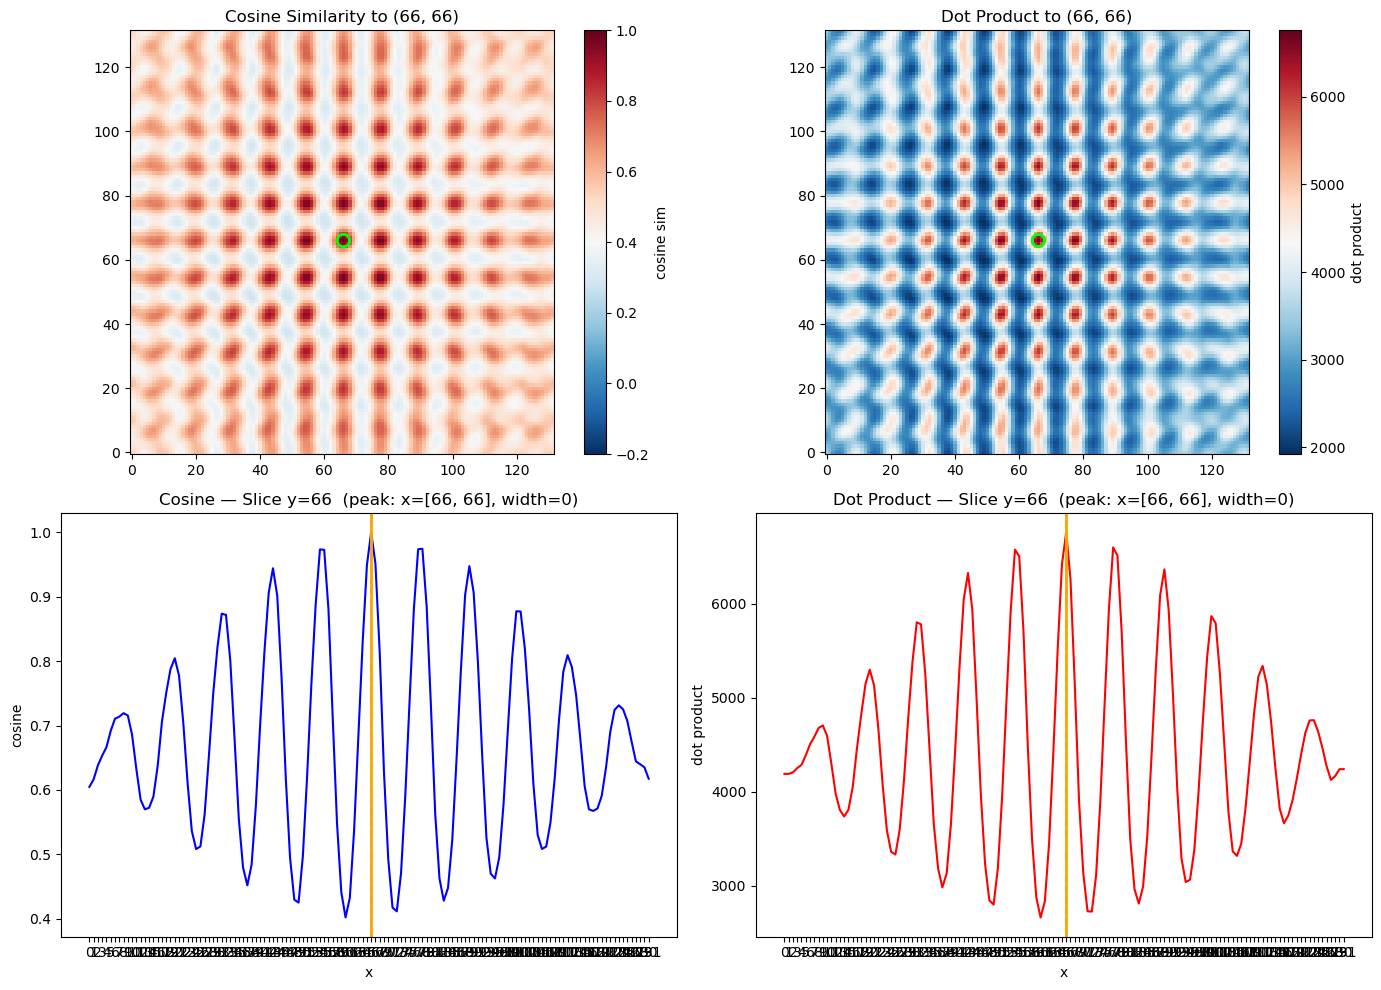

In [30]:
# --- Similarity maps from a reference point: cosine vs dot product ---
ref_x, ref_y = env_size // 2, env_size // 2
ref_idx = ref_y * env_size + ref_x

# Cosine similarity (normalized)
ref_vec_normed = pop_normed[ref_idx]
cosine_sims = pop_normed @ ref_vec_normed
cosine_map = cosine_sims.reshape(env_size, env_size)

# Dot product similarity (unnormalized)
ref_vec_raw = pop_vectors[ref_idx]
dot_sims = pop_vectors @ ref_vec_raw
dot_map = dot_sims.reshape(env_size, env_size)

def find_peak_bounds(slc, peak_idx):
    """Find the points on either side of peak where the value drops below
    the max value found outside the peak's contiguous region."""
    # Walk outward from peak to find the contiguous region above the
    # secondary max (highest value not in the main peak)
    # First pass: find contiguous descent from peak
    left = peak_idx
    while left > 0 and slc[left - 1] <= slc[left]:
        left -= 1
    right = peak_idx
    while right < len(slc) - 1 and slc[right + 1] <= slc[right]:
        right += 1
    # Max outside this contiguous descent
    outside = np.concatenate([slc[:left], slc[right+1:]])
    if len(outside) == 0:
        return 0, len(slc) - 1
    thresh = outside.max()
    # Now find where the slice crosses this threshold on each side
    left_bound = peak_idx
    while left_bound > 0 and slc[left_bound - 1] > thresh:
        left_bound -= 1
    right_bound = peak_idx
    while right_bound < len(slc) - 1 and slc[right_bound + 1] > thresh:
        right_bound += 1
    return left_bound, right_bound

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cosine map
im0 = axes[0, 0].imshow(cosine_map, origin="lower", cmap="RdBu_r", vmin=-0.2, vmax=1.0)
axes[0, 0].scatter(ref_x, ref_y, s=80, facecolors="none", edgecolors="lime", linewidths=2)
axes[0, 0].set_title(f"Cosine Similarity to ({ref_x}, {ref_y})")
plt.colorbar(im0, ax=axes[0, 0], label="cosine sim")

# Dot product map
im1 = axes[0, 1].imshow(dot_map, origin="lower", cmap="RdBu_r")
axes[0, 1].scatter(ref_x, ref_y, s=80, facecolors="none", edgecolors="lime", linewidths=2)
axes[0, 1].set_title(f"Dot Product to ({ref_x}, {ref_y})")
plt.colorbar(im1, ax=axes[0, 1], label="dot product")

# # --- Horizontal slices with peak bounds ---
for ax, slc_data, color, label in [
    (axes[1, 0], cosine_map[ref_y, :], "b", "Cosine"),
    (axes[1, 1], dot_map[ref_y, :], "r", "Dot Product"),
]:
    ax.plot(slc_data, f"{color}-", lw=1.5)
    ax.axvline(ref_x, color="lime", ls="--", alpha=0.7)
    lb, rb = find_peak_bounds(slc_data, ref_x)
    ax.axvline(lb, color="orange", ls="-", lw=2, alpha=0.8)
    ax.axvline(rb, color="orange", ls="-", lw=2, alpha=0.8)
    ax.set_xlabel("x"); ax.set_ylabel(label.lower())
    ax.set_title(f"{label} — Slice y={ref_y}  (peak: x=[{lb}, {rb}], width={rb - lb})")
    ax.set_xticks(range(env_size))

plt.tight_layout()
plt.show()

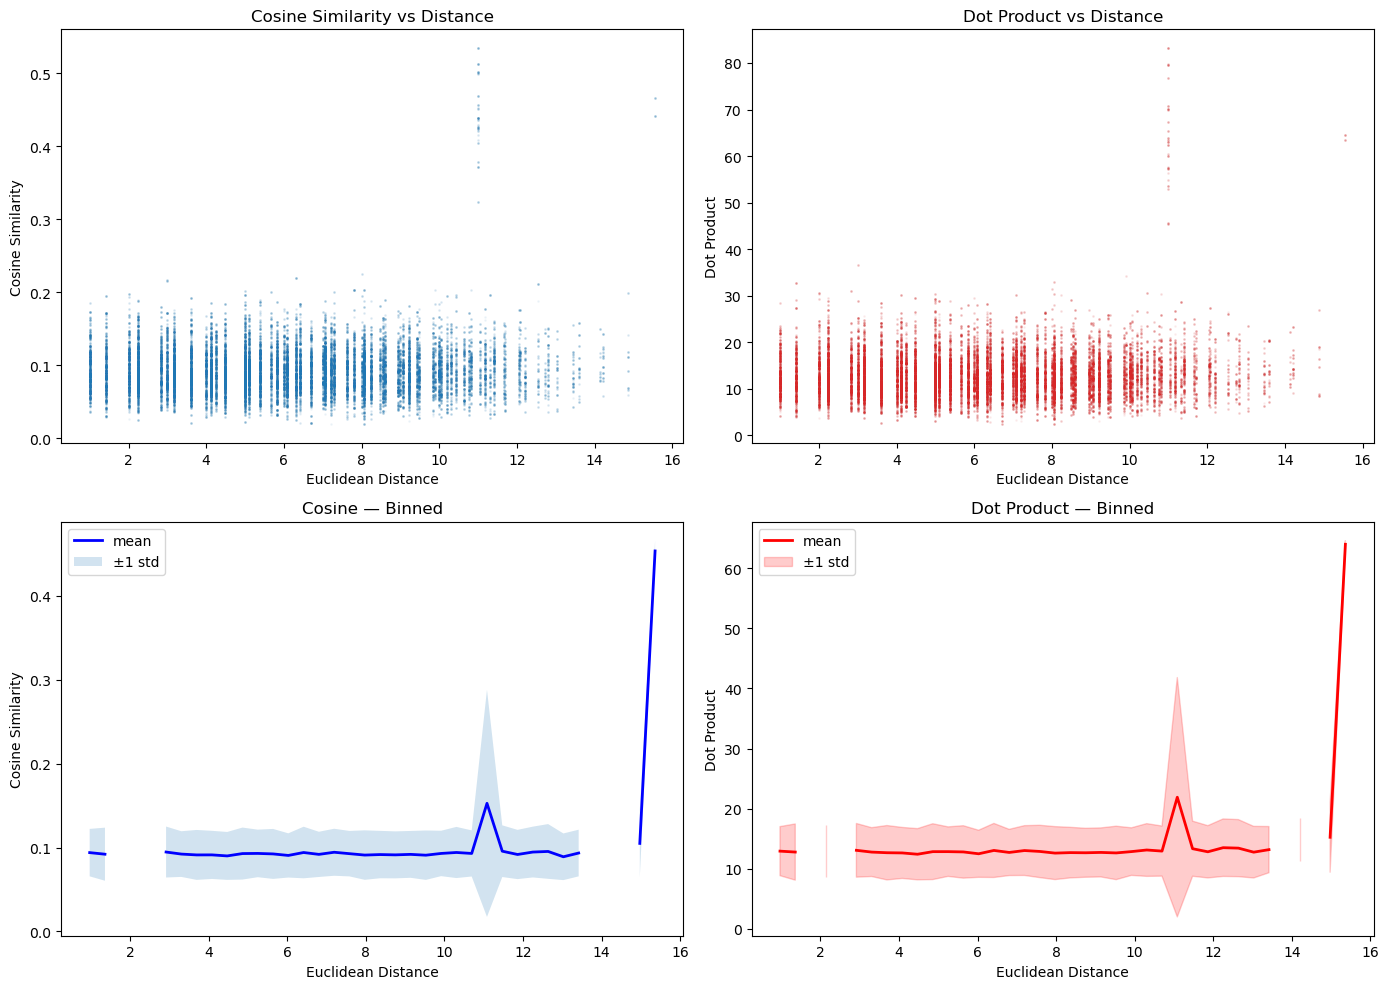

Cosine       — Pearson: 0.0532, Spearman: 0.0131
Dot product  — Pearson: 0.0619, Spearman: 0.0244


In [46]:
# --- Similarity vs Distance scatter: cosine and dot product ---
n_pairs = 50000
N = pop_normed.shape[0]
rng = np.random.default_rng(42)
idx_i = rng.integers(0, N, size=n_pairs)
idx_j = rng.integers(0, N, size=n_pairs)
mask = idx_i != idx_j
idx_i, idx_j = idx_i[mask], idx_j[mask]

# Euclidean distance
dists = np.linalg.norm(coords[idx_i] - coords[idx_j], axis=1)

# Cosine similarity
cosine_sims = np.sum(pop_normed[idx_i] * pop_normed[idx_j], axis=1)

# Dot product similarity (unnormalized)
dot_sims = np.sum(pop_vectors[idx_i] * pop_vectors[idx_j], axis=1)

# --- Binning helper ---
def bin_stats(x, y, n_bins=40):
    bin_edges = np.linspace(0, x.max(), n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bi = np.clip(np.digitize(x, bin_edges) - 1, 0, n_bins - 1)
    means = np.array([y[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)])
    stds = np.array([y[bi == b].std() if (bi == b).any() else np.nan for b in range(n_bins)])
    return bin_centers, means, stds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cosine scatter
axes[0, 0].scatter(dists, cosine_sims, s=1, alpha=0.05, rasterized=True)
axes[0, 0].set_xlabel("Euclidean Distance"); axes[0, 0].set_ylabel("Cosine Similarity")
axes[0, 0].set_title("Cosine Similarity vs Distance")

# Cosine binned
bc, bm, bs = bin_stats(dists, cosine_sims)
axes[1, 0].plot(bc, bm, "b-", lw=2, label="mean")
axes[1, 0].fill_between(bc, bm - bs, bm + bs, alpha=0.2, label="±1 std")
axes[1, 0].set_xlabel("Euclidean Distance"); axes[1, 0].set_ylabel("Cosine Similarity")
axes[1, 0].set_title("Cosine — Binned"); axes[1, 0].legend()

# Dot product scatter
axes[0, 1].scatter(dists, dot_sims, s=1, alpha=0.05, c="tab:red", rasterized=True)
axes[0, 1].set_xlabel("Euclidean Distance"); axes[0, 1].set_ylabel("Dot Product")
axes[0, 1].set_title("Dot Product vs Distance")

# Dot product binned
bc, bm, bs = bin_stats(dists, dot_sims)
axes[1, 1].plot(bc, bm, "r-", lw=2, label="mean")
axes[1, 1].fill_between(bc, bm - bs, bm + bs, alpha=0.2, color="red", label="±1 std")
axes[1, 1].set_xlabel("Euclidean Distance"); axes[1, 1].set_ylabel("Dot Product")
axes[1, 1].set_title("Dot Product — Binned"); axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Correlation stats
for name, sims in [("Cosine", cosine_sims), ("Dot product", dot_sims)]:
    pe, _ = pearsonr(dists, sims)
    sp, _ = spearmanr(dists, sims)
    print(f"{name:12s} — Pearson: {pe:.4f}, Spearman: {sp:.4f}")

## 4. Hippocampal Representation Visualization

Dimensionality reduction on place-cell population vectors to visualize the structure of the hippocampal map.

Explained variance ratio (top 3): [0.0077704  0.0074653  0.00723536]
Cumulative: [0.0077704  0.0152357  0.02247106]


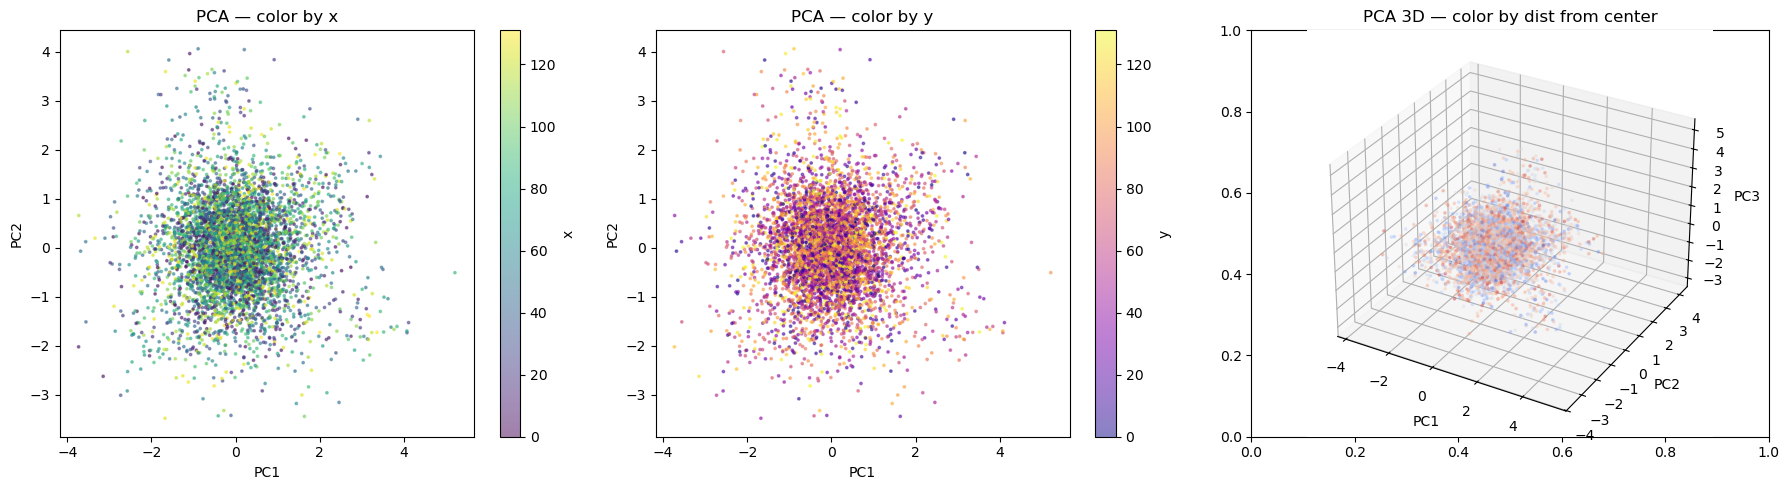

In [41]:
from sklearn.decomposition import PCA

# --- PCA on place-cell population vectors ---
# Subsample for speed (full scaffold can be huge)
n_sub = min(5000, pop_vectors.shape[0])
sub_idx = np.random.choice(pop_vectors.shape[0], n_sub, replace=False)
pop_sub = pop_vectors[sub_idx]
coords_sub = coords[sub_idx]

pca = PCA(n_components=3)
pop_pca = pca.fit_transform(pop_sub)

print(f"Explained variance ratio (top 3): {pca.explained_variance_ratio_}")
print(f"Cumulative: {pca.explained_variance_ratio_.cumsum()}")

# Color by spatial x, y
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc0 = axes[0].scatter(pop_pca[:, 0], pop_pca[:, 1], c=coords_sub[:, 0], s=3, alpha=0.5, cmap="viridis", rasterized=True)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].set_title("PCA — color by x")
plt.colorbar(sc0, ax=axes[0], label="x")

sc1 = axes[1].scatter(pop_pca[:, 0], pop_pca[:, 1], c=coords_sub[:, 1], s=3, alpha=0.5, cmap="plasma", rasterized=True)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].set_title("PCA — color by y")
plt.colorbar(sc1, ax=axes[1], label="y")

# 3D scatter
ax3d = fig.add_subplot(1, 3, 3, projection="3d")
sc2 = ax3d.scatter(pop_pca[:, 0], pop_pca[:, 1], pop_pca[:, 2],
                   c=np.linalg.norm(coords_sub - coords_sub.mean(0), axis=1),
                   s=3, alpha=0.3, cmap="coolwarm", rasterized=True)
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.set_title("PCA 3D — color by dist from center")

plt.tight_layout()
plt.show()

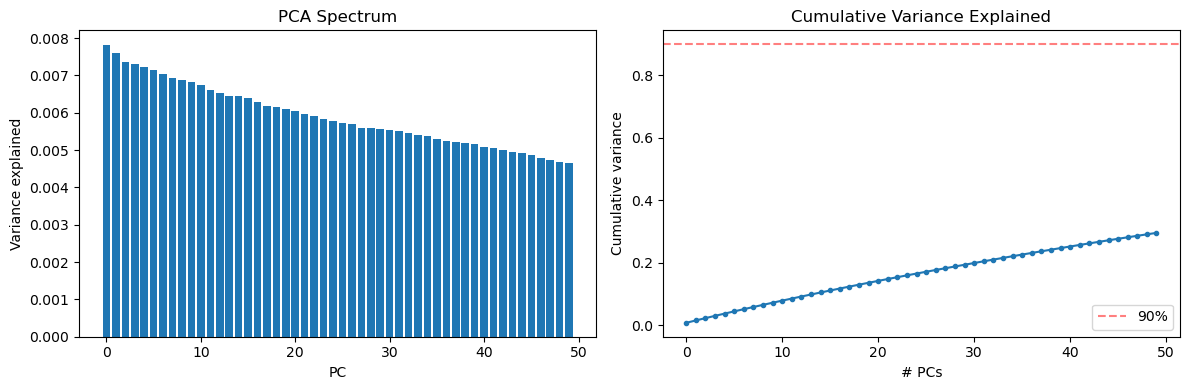

PCs for 90% variance: 51


In [42]:
# --- Variance explained spectrum ---
pca_full = PCA(n_components=min(50, Np))
pca_full.fit(pop_sub)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pca_full.explained_variance_ratio_)), pca_full.explained_variance_ratio_)
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Variance explained")
axes[0].set_title("PCA Spectrum")

axes[1].plot(pca_full.explained_variance_ratio_.cumsum(), "o-", ms=3)
axes[1].set_xlabel("# PCs"); axes[1].set_ylabel("Cumulative variance")
axes[1].set_title("Cumulative Variance Explained")
axes[1].axhline(0.9, color="r", ls="--", alpha=0.5, label="90%")
axes[1].legend()

plt.tight_layout()
plt.show()

n90 = np.searchsorted(pca_full.explained_variance_ratio_.cumsum(), 0.9) + 1
print(f"PCs for 90% variance: {n90}")

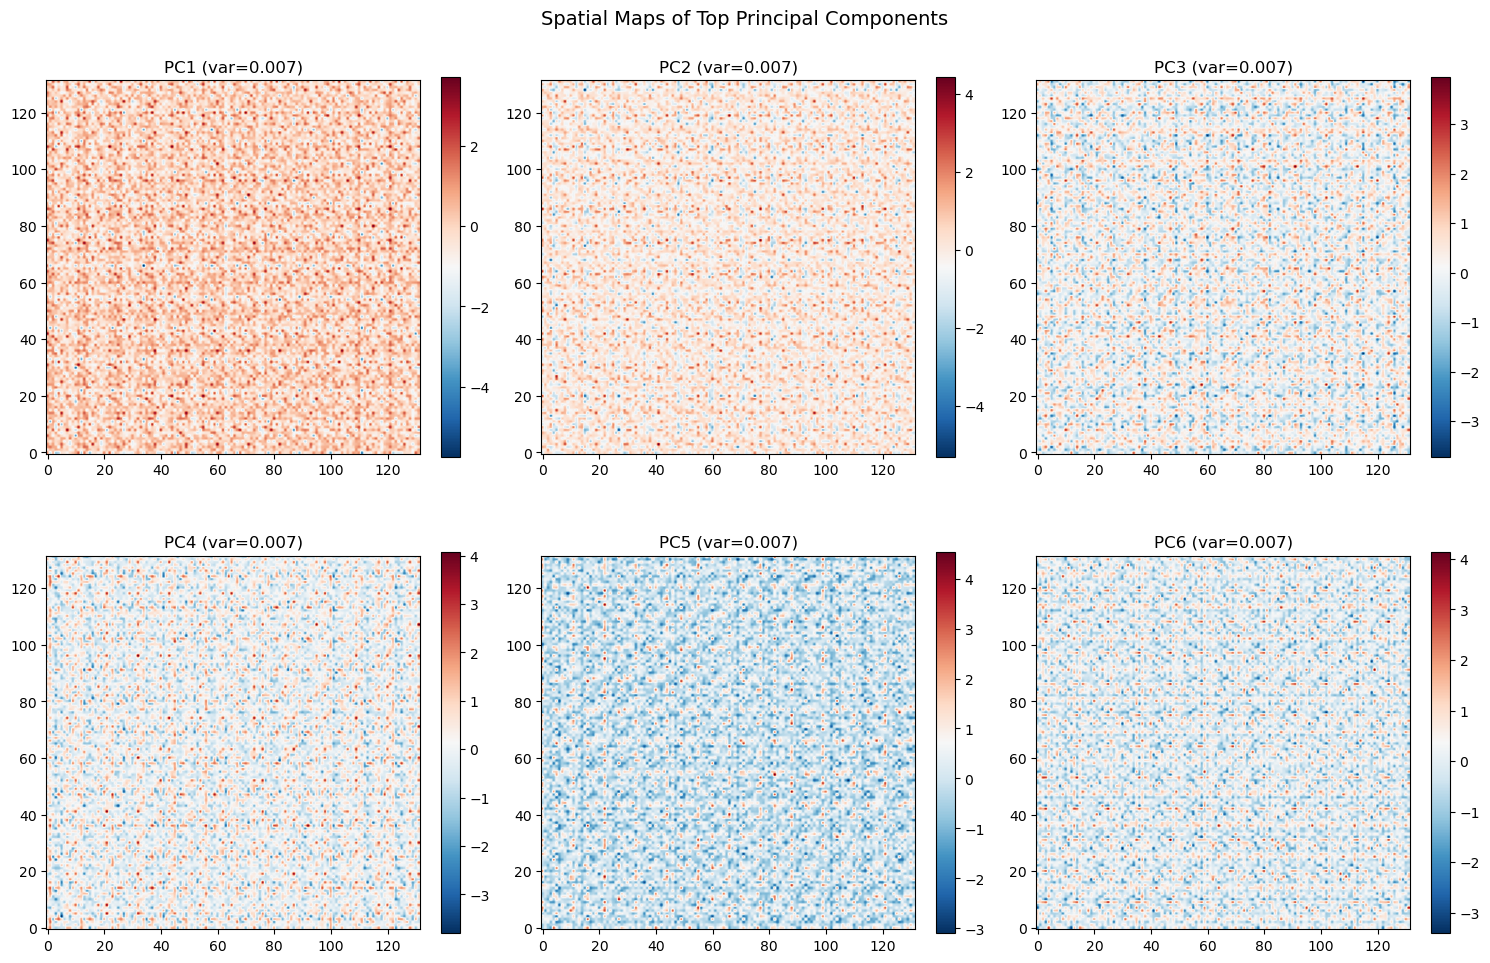

In [43]:
# --- Spatial maps of top PCs ---
# Project ALL positions through PCA to see spatial structure of each component
pca3 = PCA(n_components=6)
pop_all_pca = pca3.fit_transform(pop_vectors)  # (Npos*Npos, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    pc_map = pop_all_pca[:, i].reshape(Npos, Npos)
    im = ax.imshow(pc_map, origin="lower", cmap="RdBu_r")
    ax.set_title(f"PC{i+1} (var={pca3.explained_variance_ratio_[i]:.3f})")
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Spatial Maps of Top Principal Components", fontsize=14)
plt.tight_layout()
plt.show()

# Ideal Place Cell Exp

Total place fields: 5070
Place cells: 1000
Avg fields per cell: 5.1

Reference point: (100, 100)
Active cells at reference (rate > 0.01): 576


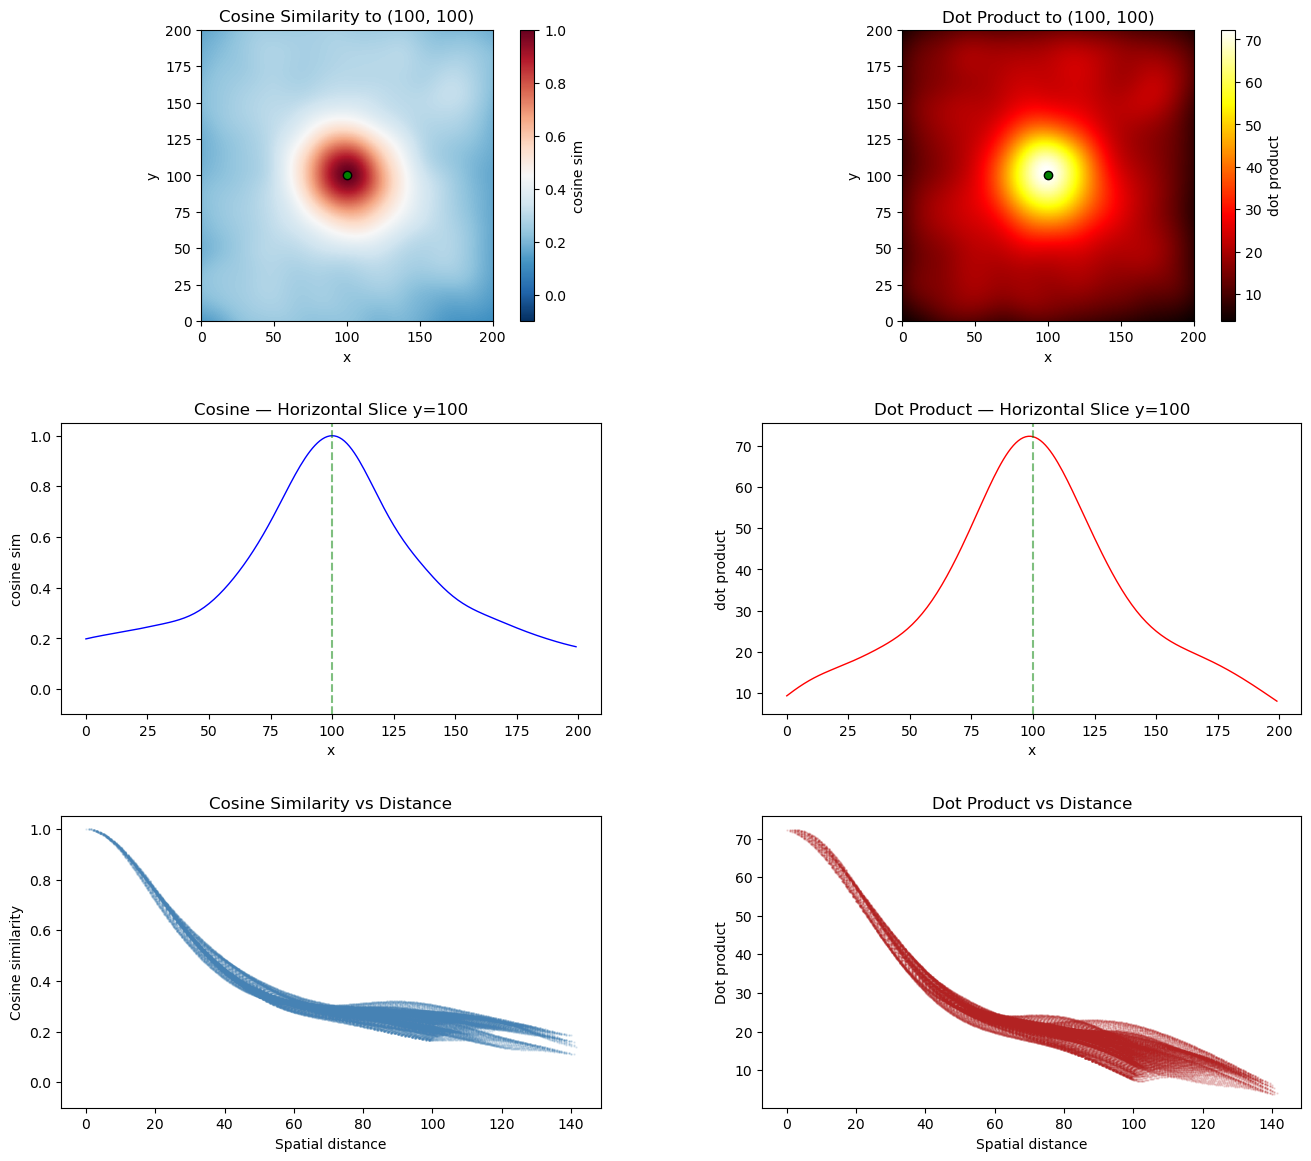

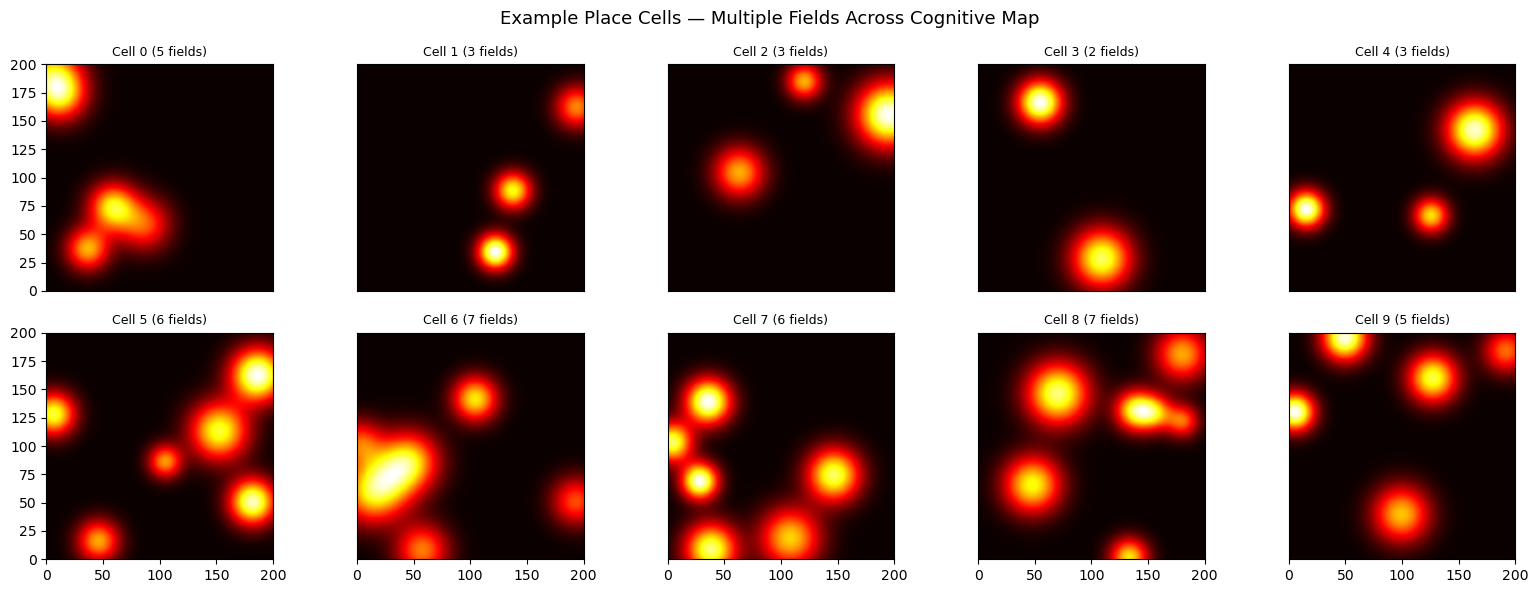


Done.


In [1]:
"""
Place Cell Population Across Full Cognitive Map
================================================
- The cognitive map is a large 2D space (the full grid scaffold range).
- Multiple "rooms" are placed as random patches within this map.
- Each place cell has a small number of Gaussian fields scattered
  across the map (some cells active in multiple rooms, some in just one).
- Global similarity analysis: how does population vector similarity
  from a reference point behave across the entire cognitive map?
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---- Parameters ----
map_size = 200             # full cognitive map: [0, map_size] x [0, map_size]
Np = 1000                  # number of place cells
fields_per_cell = 5        # average number of fields per cell (Poisson)
field_width_range = (10, 20) # sigma of each Gaussian field
resolution = 1           # spatial resolution for evaluation (pixels)

np.random.seed(42)

# ---- Generate place cell fields ----
# Each cell has a random number of fields placed randomly in the full map
centers = []    # list of (cell_idx, x, y, sigma, peak_rate)
for cell in range(Np):
    n_fields = max(1, np.random.poisson(fields_per_cell))
    for _ in range(n_fields):
        cx = np.random.uniform(0, map_size)
        cy = np.random.uniform(0, map_size)
        sigma = np.random.uniform(field_width_range[0], field_width_range[1])
        peak = np.random.uniform(0.5, 1.0)
        centers.append((cell, cx, cy, sigma, peak))

centers = np.array(centers)
print(f"Total place fields: {len(centers)}")
print(f"Place cells: {Np}")
print(f"Avg fields per cell: {len(centers) / Np:.1f}")

# ---- Evaluate population vectors across the map ----
xs = np.arange(0, map_size, resolution)
ys = np.arange(0, map_size, resolution)
nx, ny = len(xs), len(ys)

# Build population matrix efficiently
# pop[i, j, cell] = sum of all that cell's fields evaluated at (xs[i], ys[j])
pop = np.zeros((nx, ny, Np), dtype=np.float32)

for (cell_idx, cx, cy, sigma, peak) in centers:
    cell = int(cell_idx)
    # Only compute within a window around each field center for speed
    radius = 4 * sigma
    ix_min = max(0, int((cx - radius) / resolution))
    ix_max = min(nx, int((cx + radius) / resolution) + 1)
    iy_min = max(0, int((cy - radius) / resolution))
    iy_max = min(ny, int((cy + radius) / resolution) + 1)

    for i in range(ix_min, ix_max):
        for j in range(iy_min, iy_max):
            dx = xs[i] - cx
            dy = ys[j] - cy
            pop[i, j, cell] += peak * np.exp(-(dx**2 + dy**2) / (2 * sigma**2))

# ---- Reference point: center of map ----
ref_x = map_size // 2
ref_y = map_size // 2
ref_ix = np.argmin(np.abs(xs - ref_x))
ref_iy = np.argmin(np.abs(ys - ref_y))
ref_vec = pop[ref_ix, ref_iy, :]

print(f"\nReference point: ({ref_x}, {ref_y})")
print(f"Active cells at reference (rate > 0.01): {np.sum(ref_vec > 0.01)}")

# ---- Compute similarity maps ----
dot_map = np.zeros((nx, ny))
cos_map = np.zeros((nx, ny))
dist_map = np.zeros((nx, ny))

ref_norm = np.linalg.norm(ref_vec)

for i in range(nx):
    for j in range(ny):
        v = pop[i, j, :]
        dot_map[i, j] = np.dot(ref_vec, v)
        norm_v = np.linalg.norm(v)
        if ref_norm > 0 and norm_v > 0:
            cos_map[i, j] = np.dot(ref_vec, v) / (ref_norm * norm_v)
        dist_map[i, j] = np.sqrt((xs[i] - ref_x)**2 + (ys[j] - ref_y)**2)

# ---- Plot ----
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# 2D cosine similarity
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(cos_map.T, origin='lower', extent=[0, map_size, 0, map_size],
               cmap='RdBu_r', vmin=-0.1, vmax=1.0)
ax.plot(ref_x, ref_y, 'go', markersize=6, markeredgecolor='k')
ax.set_title(f'Cosine Similarity to ({ref_x}, {ref_y})')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='cosine sim')

# 2D dot product
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(dot_map.T, origin='lower', extent=[0, map_size, 0, map_size],
               cmap='hot')
ax.plot(ref_x, ref_y, 'go', markersize=6, markeredgecolor='k')
ax.set_title(f'Dot Product to ({ref_x}, {ref_y})')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='dot product')

# Horizontal slice — cosine
ax = fig.add_subplot(gs[1, 0])
slice_cos = cos_map[:, ref_iy]
ax.plot(xs, slice_cos, 'b-', lw=1)
ax.axvline(ref_x, color='g', ls='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('cosine sim')
ax.set_title(f'Cosine — Horizontal Slice y={ref_y}')
ax.set_ylim(-0.1, 1.05)

# Horizontal slice — dot product
ax = fig.add_subplot(gs[1, 1])
slice_dot = dot_map[:, ref_iy]
ax.plot(xs, slice_dot, 'r-', lw=1)
ax.axvline(ref_x, color='g', ls='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('dot product')
ax.set_title(f'Dot Product — Horizontal Slice y={ref_y}')

# Scatter: similarity vs distance
ax = fig.add_subplot(gs[2, 0])
flat_dist = dist_map.flatten()
flat_cos = cos_map.flatten()
ax.scatter(flat_dist, flat_cos, s=0.5, alpha=0.15, c='steelblue')
ax.set_xlabel('Spatial distance')
ax.set_ylabel('Cosine similarity')
ax.set_title('Cosine Similarity vs Distance')
ax.set_ylim(-0.1, 1.05)

ax = fig.add_subplot(gs[2, 1])
flat_dot = dot_map.flatten()
ax.scatter(flat_dist, flat_dot, s=0.5, alpha=0.15, c='firebrick')
ax.set_xlabel('Spatial distance')
ax.set_ylabel('Dot product')
ax.set_title('Dot Product vs Distance')

plt.savefig('cognitive_map_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Show some example cells with multiple fields ----
fig2, axes2 = plt.subplots(2, 5, figsize=(16, 6))
for idx in range(10):
    ax = axes2[idx // 5, idx % 5]
    field = pop[:, :, idx].T
    ax.imshow(field, origin='lower', extent=[0, map_size, 0, map_size],
              cmap='hot', vmin=0)
    n_fields_cell = np.sum(centers[:, 0] == idx)
    ax.set_title(f'Cell {idx} ({int(n_fields_cell)} fields)', fontsize=9)
    if idx % 5 != 0:
        ax.set_yticks([])
    if idx < 5:
        ax.set_xticks([])

fig2.suptitle('Example Place Cells — Multiple Fields Across Cognitive Map', fontsize=13)
plt.tight_layout()
plt.savefig('cognitive_map_fields.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDone.")

Reference point: (500, 500)
Place cells: 500
Active cells at reference (rate > 0.01): 2
Mean rate at reference: 0.0005


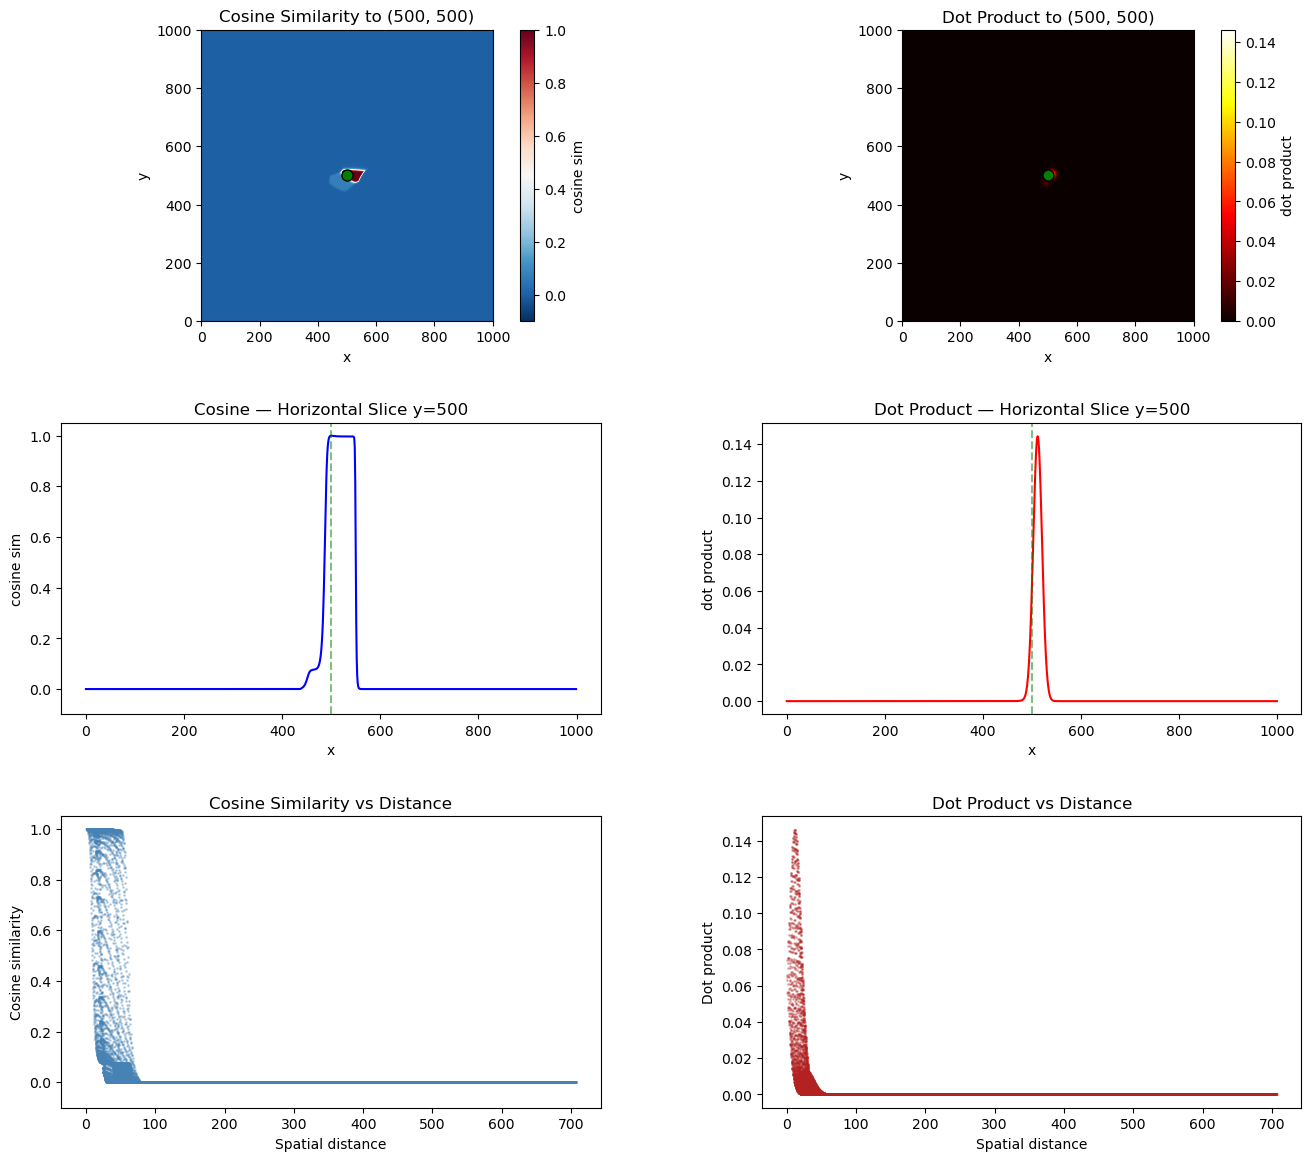

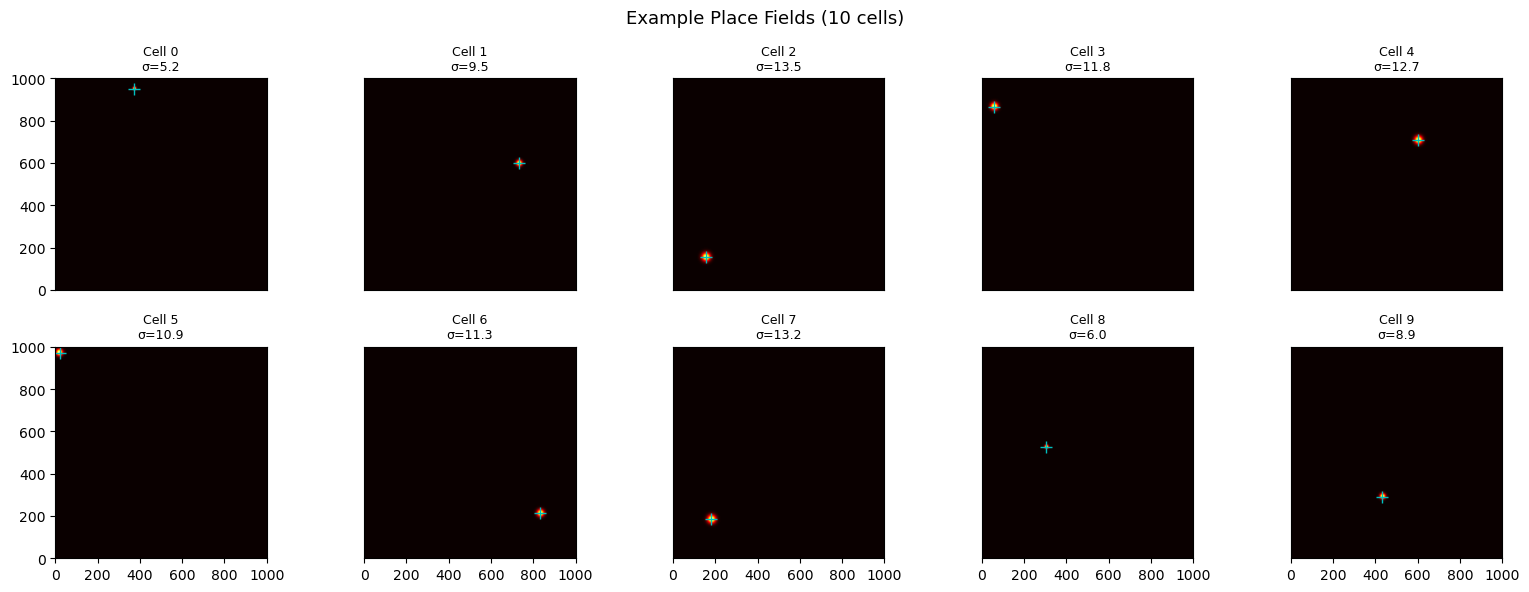


Done.


In [27]:
"""
Bioplausible Place Cell Population Code — Similarity Analysis
==============================================================
Each place cell has a Gaussian receptive field centered at a random
location in 2D space, with a random field width. The population
vector at any location is the vector of all cells' firing rates.

We test whether the population vector similarity (dot product and
cosine) decays smoothly with spatial distance from a reference point.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---- Parameters ----
Np = 500                  # number of place cells
space_size = 1000          # environment is [0, space_size] x [0, space_size]
resolution = 1            # spatial resolution for evaluation
field_width_range = (3, 15)  # range of place field widths (std dev)
sparsity = 0.2            # fraction of space where each cell is meaningfully active

# ---- Generate place cell population ----
np.random.seed(42)

# Random field centers uniformly distributed in space
centers = np.random.uniform(0, space_size, size=(Np, 2))

# Random field widths (sigma)
sigmas = np.random.uniform(field_width_range[0], field_width_range[1], size=Np)

# Peak firing rates (random, biologically variable)
peak_rates = np.random.uniform(0.5, 1.0, size=Np)

# ---- Evaluate population vectors across space ----
xs = np.arange(0, space_size, resolution)
ys = np.arange(0, space_size, resolution)
nx, ny = len(xs), len(ys)

# Population matrix: shape (nx, ny, Np)
pop = np.zeros((nx, ny, Np))

for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        pos = np.array([x, y])
        dists_sq = np.sum((centers - pos) ** 2, axis=1)
        pop[i, j, :] = peak_rates * np.exp(-dists_sq / (2 * sigmas ** 2))

# ---- Reference point: center of space ----
ref_x = space_size // 2
ref_y = space_size // 2
ref_ix = np.argmin(np.abs(xs - ref_x))
ref_iy = np.argmin(np.abs(ys - ref_y))
ref_vec = pop[ref_ix, ref_iy, :]

print(f"Reference point: ({ref_x}, {ref_y})")
print(f"Place cells: {Np}")
print(f"Active cells at reference (rate > 0.01): {np.sum(ref_vec > 0.01)}")
print(f"Mean rate at reference: {np.mean(ref_vec):.4f}")

# ---- Compute similarity maps ----
dot_map = np.zeros((nx, ny))
cos_map = np.zeros((nx, ny))
dist_map = np.zeros((nx, ny))

ref_norm = np.linalg.norm(ref_vec)

for i in range(nx):
    for j in range(ny):
        v = pop[i, j, :]
        dot_map[i, j] = np.dot(ref_vec, v)
        norm_v = np.linalg.norm(v)
        if ref_norm > 0 and norm_v > 0:
            cos_map[i, j] = np.dot(ref_vec, v) / (ref_norm * norm_v)
        dist_map[i, j] = np.sqrt((xs[i] - ref_x)**2 + (ys[j] - ref_y)**2)

# ---- Plot ----
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# 2D cosine similarity
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(cos_map.T, origin='lower', extent=[0, space_size, 0, space_size],
               cmap='RdBu_r', vmin=-0.1, vmax=1.0)
ax.plot(ref_x, ref_y, 'go', markersize=8, markeredgecolor='k')
ax.set_title(f'Cosine Similarity to ({ref_x}, {ref_y})')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='cosine sim')

# 2D dot product
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(dot_map.T, origin='lower', extent=[0, space_size, 0, space_size],
               cmap='hot')
ax.plot(ref_x, ref_y, 'go', markersize=8, markeredgecolor='k')
ax.set_title(f'Dot Product to ({ref_x}, {ref_y})')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='dot product')

# Horizontal slice — cosine
ax = fig.add_subplot(gs[1, 0])
slice_cos = cos_map[:, ref_iy]
ax.plot(xs, slice_cos, 'b-', lw=1.5)
ax.axvline(ref_x, color='g', ls='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('cosine sim')
ax.set_title(f'Cosine — Horizontal Slice y={ref_y}')
ax.set_ylim(-0.1, 1.05)

# Horizontal slice — dot product
ax = fig.add_subplot(gs[1, 1])
slice_dot = dot_map[:, ref_iy]
ax.plot(xs, slice_dot, 'r-', lw=1.5)
ax.axvline(ref_x, color='g', ls='--', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('dot product')
ax.set_title(f'Dot Product — Horizontal Slice y={ref_y}')

# Scatter: similarity vs distance
ax = fig.add_subplot(gs[2, 0])
flat_dist = dist_map.flatten()
flat_cos = cos_map.flatten()
ax.scatter(flat_dist, flat_cos, s=1, alpha=0.3, c='steelblue')
ax.set_xlabel('Spatial distance')
ax.set_ylabel('Cosine similarity')
ax.set_title('Cosine Similarity vs Distance')
ax.set_ylim(-0.1, 1.05)

ax = fig.add_subplot(gs[2, 1])
flat_dot = dot_map.flatten()
ax.scatter(flat_dist, flat_dot, s=1, alpha=0.3, c='firebrick')
ax.set_xlabel('Spatial distance')
ax.set_ylabel('Dot product')
ax.set_title('Dot Product vs Distance')

plt.savefig('place_cell_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Show a few example place fields ----
fig2, axes2 = plt.subplots(2, 5, figsize=(16, 6))
for idx in range(10):
    ax = axes2[idx // 5, idx % 5]
    field = pop[:, :, idx].T
    ax.imshow(field, origin='lower', extent=[0, space_size, 0, space_size],
              cmap='hot')
    ax.set_title(f'Cell {idx}\nσ={sigmas[idx]:.1f}', fontsize=9)
    ax.plot(centers[idx, 0], centers[idx, 1], 'c+', markersize=8)
    if idx % 5 != 0:
        ax.set_yticks([])
    if idx < 5:
        ax.set_xticks([])

fig2.suptitle('Example Place Fields (10 cells)', fontsize=13)
plt.tight_layout()
plt.savefig('place_cell_fields.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDone.")

/tmp/ipykernel_383151/1384674942.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


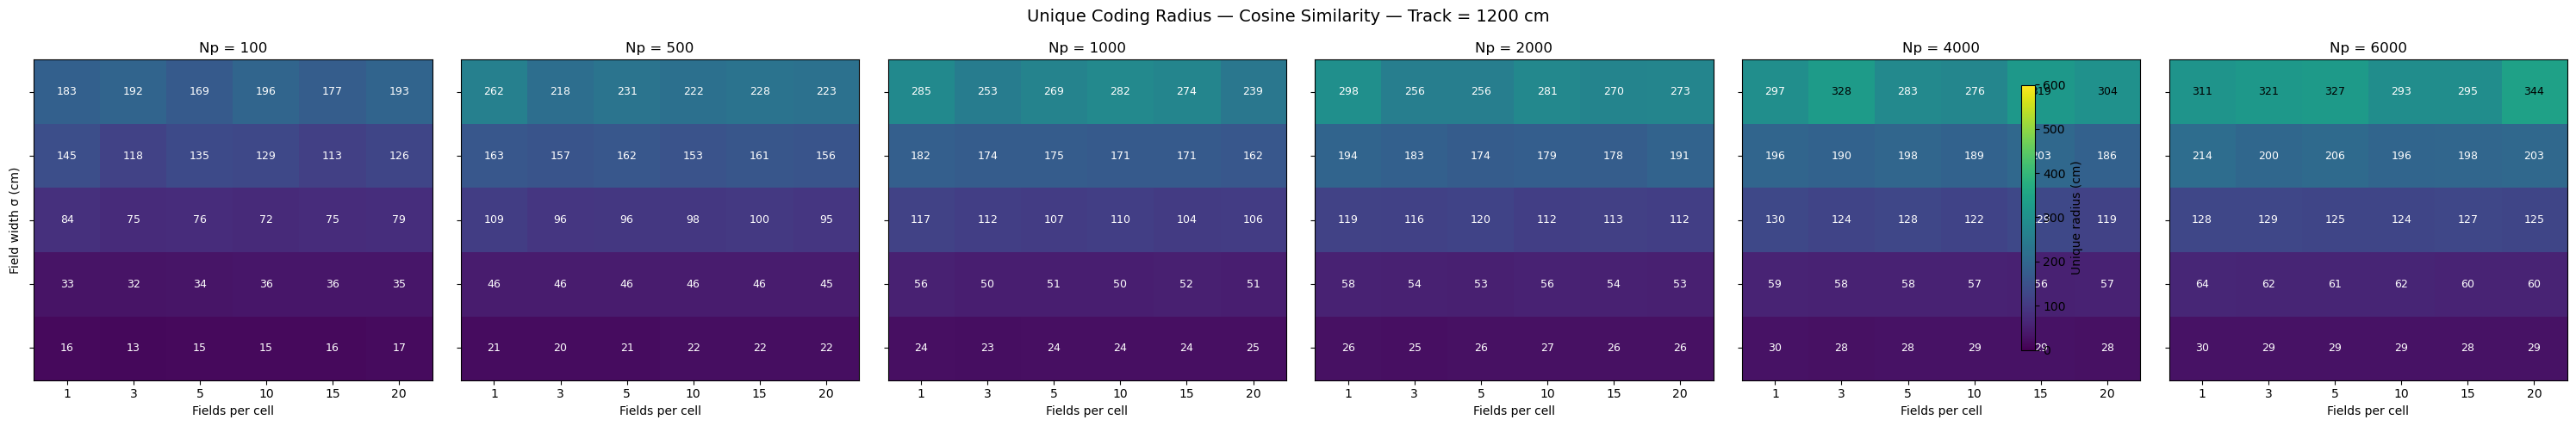

Done.


In [13]:
"""
Read unique_radius_sweep.csv and plot heatmaps of unique coding radius.
Cosine similarity only.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load ----
df = pd.read_csv('unique_radius_sweep.csv')

df['field_width'] = list(zip(df['field_width_min'], df['field_width_max']))
field_widths_list = sorted(df['field_width'].unique(), key=lambda x: x[0])
Np_list = sorted(df['Np'].unique())
fields_per_cell_list = sorted(df['fields_per_cell'].unique())

track_length = 1200  # must match sweep script

# ---- Plot ----
fig, axes = plt.subplots(1, len(Np_list), figsize=(5 * len(Np_list), 5), sharey=True)

for ax_idx, Np in enumerate(Np_list):
    ax = axes[ax_idx]
    mat = np.zeros((len(field_widths_list), len(fields_per_cell_list)))

    for i, fw in enumerate(field_widths_list):
        for j, fpc in enumerate(fields_per_cell_list):
            mask = ((df['field_width'] == fw) &
                    (df['Np'] == Np) &
                    (df['fields_per_cell'] == fpc))
            vals = df.loc[mask, 'unique_radius_cosine_cm']
            mat[i, j] = vals.values[0] if len(vals) > 0 else 0

    im = ax.imshow(mat, aspect='auto', cmap='viridis', origin='lower',
                   vmin=0, vmax=track_length // 2)
    ax.set_xticks(range(len(fields_per_cell_list)))
    ax.set_xticklabels(fields_per_cell_list)
    ax.set_xlabel('Fields per cell')

    if ax_idx == 0:
        ax.set_yticks(range(len(field_widths_list)))
        ax.set_yticklabels([f"{fw[0]}-{fw[1]}" for fw in field_widths_list])
        ax.set_ylabel('Field width σ (cm)')
    else:
        ax.set_yticks(range(len(field_widths_list)))
        ax.set_yticklabels([])

    ax.set_title(f'Np = {Np}')

    for i in range(len(field_widths_list)):
        for j in range(len(fields_per_cell_list)):
            ax.text(j, i, f'{mat[i, j]:.0f}', ha='center', va='center',
                    color='white' if mat[i, j] < track_length // 4 else 'black',
                    fontsize=9)

plt.colorbar(im, ax=axes, label='Unique radius (cm)', shrink=0.8)
fig.suptitle(f'Unique Coding Radius — Cosine Similarity — Track = {track_length} cm', fontsize=14)
plt.tight_layout()
plt.savefig('unique_radius_sweep_from_csv.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done.")

150 rows from /orcd/home/002/jackking/cls/cosine_width_sweep.csv


/tmp/ipykernel_559158/1137380397.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


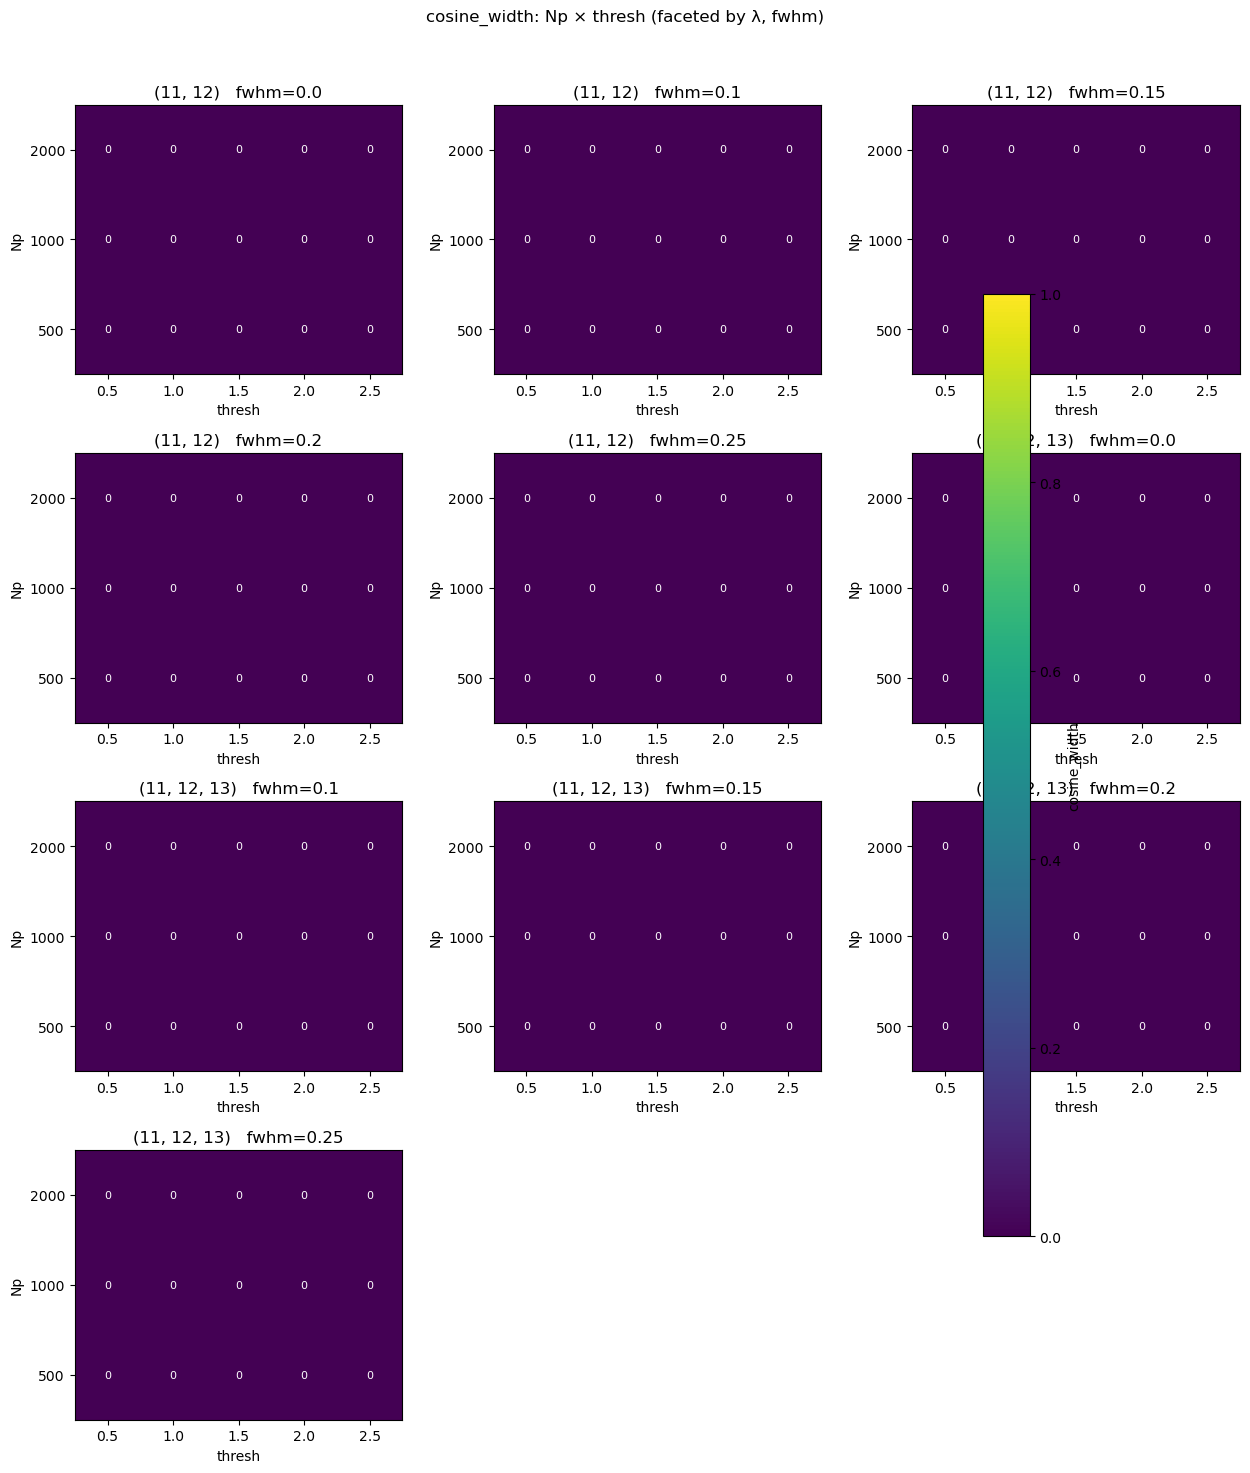

In [2]:
# Cosine width sweep — **visualization** (run the sweep as a script, then load CSV here).
#
# From repository root (directory containing `cls/`):
#
#     python sweep_cosine_width.py -o cosine_width_sweep.csv
#
# Adjust grids inside `sweep_cosine_width.py` (defaults at top) or pass `-o` for path.

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _resolve_csv_path() -> Path:
    candidates: list[Path] = []
    root = globals().get("PROJECT_ROOT")
    if root:
        candidates.append(Path(root) / "cosine_width_sweep.csv")
    candidates.append(Path.cwd() / "cosine_width_sweep.csv")
    candidates.append(Path.cwd().parent / "cosine_width_sweep.csv")
    for p in candidates:
        if p.is_file():
            return p.resolve()
    tried = ", ".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "cosine_width_sweep.csv not found. Tried: "
        + tried
        + " — run: python sweep_cosine_width.py -o cosine_width_sweep.csv (repo root)."
    )


def plot_cosine_width_facets(df: pd.DataFrame, value_col: str = "cosine_width") -> None:
    """Grid of heatmaps: rows Np, columns thresh; one panel per (lambdas, fwhm_ratio)."""
    keys = ["lambdas", "fwhm_ratio"]
    combos = df[keys].drop_duplicates()
    n = len(combos)
    ncols = min(3, max(1, n))
    nrows = int(np.ceil(n / ncols))

    vmin = float(df[value_col].min())
    vmax = float(df[value_col].max())
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise ValueError(f"Bad {value_col} range")
    if abs(vmax - vmin) < 1e-9:
        vmax = vmin + 1.0

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False
    )
    last_im = None
    for ax, (_, crow) in zip(axes.flat, combos.iterrows()):
        sub = df
        for k in keys:
            sub = sub[sub[k] == crow[k]]
        pivot = sub.pivot_table(
            index="Np", columns="thresh", values=value_col, aggfunc="first"
        )
        pivot = pivot.sort_index(axis=0).sort_index(axis=1)
        im = ax.imshow(
            pivot.values.astype(float),
            aspect="auto",
            cmap="viridis",
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )
        last_im = im
        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels([str(c) for c in pivot.columns])
        ax.set_yticks(np.arange(pivot.shape[0]))
        ax.set_yticklabels([str(i) for i in pivot.index])
        ax.set_title(f"{crow['lambdas']}   fwhm={crow['fwhm_ratio']}")
        ax.set_xlabel("thresh")
        ax.set_ylabel("Np")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = float(pivot.values[i, j])
                ax.text(
                    j,
                    i,
                    f"{val:.0f}",
                    ha="center",
                    va="center",
                    color="white" if val < (vmin + vmax) / 2 else "black",
                    fontsize=8,
                )
    for ax in axes.flat[len(combos) :]:
        ax.axis("off")
    if last_im is not None:
        fig.colorbar(
            last_im,
            ax=axes.ravel().tolist(),
            shrink=0.85,
            label=value_col,
        )
    fig.suptitle(f"{value_col}: Np × thresh (faceted by λ, fwhm)", y=1.02)
    plt.tight_layout()
    plt.show()


csv_path = _resolve_csv_path()
df = pd.read_csv(csv_path)
print(f"{len(df)} rows from {csv_path}")

plot_cosine_width_facets(df)
